# NetShield AI: Network Anomaly Detection & Threat Monitoring System
## Machine Learning Training & Evaluation Pipeline (Milestone 2)

This notebook implements the complete machine learning pipeline for **NetShield AI**, which aims to detect anomalies in network traffic and classify threats using the **UNSW-NB15** and **CICIDS2017** datasets.

### Pipeline Structure:
1. **Environment Auto-Detection**: Locates dataset paths on Kaggle (`/kaggle/input`) or locally.
2. **Data Loading & Stratified Sampling**: Handles raw datasets (including 2.8M rows in CICIDS2017) using smart sampling to run efficiently without Out-Of-Memory (OOM) errors.
3. **Pipeline A (UNSW-NB15)**:
   - **Ingestion & Preprocessing**: Cleans column whitespaces, maps attack labels, encodes categorical text (`proto`, `service`, `state`), scales numerical features.
   - **Binary Anomaly Detection**: Trains a classifier to distinguish Normal vs. Anomaly.
   - **Multiclass Threat Classification**: Trains a classifier to predict specific attack categories (e.g. Generic, Exploits, Fuzzers, DoS, Reconnaissance, etc.).
4. **Pipeline B (CICIDS2017)**:
   - **Data Cleaning**: Strips column whitespaces, cleans infinite and null values, standardizes attack label strings.
   - **Scaling & Encoding**: Prepares network flow features and scales them.
   - **Binary & Multiclass Classification**: Trains models using XGBoost.
5. **Risk Scoring Engine**: Implements a mapping function converting binary model prediction probability into four security risk tiers: **Low, Medium, High, Critical**.
6. **Diagnostic Visualizations**: Generates confusion matrices, ROC curves, and Top-15 feature importance charts.
7. **Model Saving**: Serializes models, scalers, and encoders into `.joblib` files for backend API integration.

In [1]:
import os
import glob
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    classification_report, confusion_matrix, roc_curve, auc
)
from xgboost import XGBClassifier

# Configure plotting aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 13

# Environment setup
IS_KAGGLE = os.path.exists('/kaggle/input')
print(f"Running on Kaggle environment: {IS_KAGGLE}")

Running on Kaggle environment: False


### 1. Dataset Path Auto-Detection

This function automatically resolves paths to the dataset files, supporting both local execution and Kaggle's `/kaggle/input` directories. It searches dynamically for the files to avoid hardcoding specific names.

In [2]:
def detect_dataset_paths():
    paths = {
        'unsw_train': None,
        'unsw_test': None,
        'cicids_dir': None
    }
    
    if IS_KAGGLE:
        print("Searching Kaggle input directory for datasets...")
        for root, dirs, files in os.walk('./'):
            for file in files:
                if 'UNSW_NB15_training-set.csv' in file:
                    paths['unsw_train'] = os.path.join(root, file)
                elif 'UNSW_NB15_testing-set.csv' in file:
                    paths['unsw_test'] = os.path.join(root, file)
            if 'CICIDS2017' in dirs:
                paths['cicids_dir'] = os.path.join(root, 'CICIDS2017')
            elif any(f.endswith('.csv') and 'WorkingHours' in f for f in files):
                paths['cicids_dir'] = root
        
        # Final check if CICIDS2017 directory was not resolved
        if not paths['cicids_dir']:
            for root, dirs, files in os.walk('/kaggle/input'):
                if any('Friday-WorkingHours' in f for f in files):
                    paths['cicids_dir'] = root
                    break
    else:
        print("Running locally. Resolving relative paths...")
        paths['unsw_train'] = 'UNSW-NB15 datasets/UNSW_NB15_training-set.csv'
        paths['unsw_test'] = 'UNSW-NB15 datasets/UNSW_NB15_testing-set.csv'
        paths['cicids_dir'] = 'CICIDS2017'
        
    print("Resolved dataset paths:")
    for k, v in paths.items():
        print(f"  {k}: {v}")
        if v and not os.path.exists(v):
            print(f"    [WARNING] Path '{v}' was resolved but does not exist physically!")
            
    return paths

paths = detect_dataset_paths()

Running locally. Resolving relative paths...
Resolved dataset paths:
  unsw_train: UNSW-NB15 datasets/UNSW_NB15_training-set.csv
  unsw_test: UNSW-NB15 datasets/UNSW_NB15_testing-set.csv
  cicids_dir: CICIDS2017


### 2. Run Configurations & Preprocessing Setup

To ensure code robustness, we define sample fractions. When verifying locally (Quick Run Mode), we use a tiny sample size. On Kaggle, we train on a larger fraction (e.g. 10% of CICIDS2017, which gives ~280k rows, and 100% of UNSW-NB15) to maintain standard Kaggle cell execution limits.

In [3]:
if IS_KAGGLE:
    UNSW_SAMPLE_FRAC = 1.0
    CICIDS_SAMPLE_FRAC = 0.1
    QUICK_RUN = False
else:
    UNSW_SAMPLE_FRAC = 0.05
    CICIDS_SAMPLE_FRAC = 0.01
    QUICK_RUN = True

print(f"Active Configurations:")
print(f"  UNSW-NB15 Sample Fraction: {UNSW_SAMPLE_FRAC*100}%")
print(f"  CICIDS2017 Sample Fraction: {CICIDS_SAMPLE_FRAC*100}%")
print(f"  Quick Run Mode enabled: {QUICK_RUN}")

# Create destination directories for outputs
os.makedirs('models', exist_ok=True)
os.makedirs('plots', exist_ok=True)
print("Output directories 'models/' and 'plots/' created successfully.")

Active Configurations:
  UNSW-NB15 Sample Fraction: 5.0%
  CICIDS2017 Sample Fraction: 1.0%
  Quick Run Mode enabled: True
Output directories 'models/' and 'plots/' created successfully.


### 3. Pipeline A: UNSW-NB15 Model Training

Here we load the training and testing sets, merge them for feature standardization, clean data types, encode categorical values, split them back, and train the classifiers.

In [4]:
print("Loading UNSW-NB15 datasets...")
unsw_train_raw = pd.read_csv(paths['unsw_train'])
unsw_test_raw = pd.read_csv(paths['unsw_test'])

print(f"Loaded Raw Shapes: Train={unsw_train_raw.shape}, Test={unsw_test_raw.shape}")

# Combine temporarily for unified preprocessing
unsw_train_raw['is_train'] = 1
unsw_test_raw['is_train'] = 0
unsw_full = pd.concat([unsw_train_raw, unsw_test_raw], axis=0, ignore_index=True)

# Drop ID column if it exists
if 'id' in unsw_full.columns:
    unsw_full = unsw_full.drop(columns=['id'])

print(f"Combined UNSW-NB15 shape: {unsw_full.shape}")

Loading UNSW-NB15 datasets...
Loaded Raw Shapes: Train=(82332, 45), Test=(175341, 45)
Combined UNSW-NB15 shape: (257673, 45)


#### Feature Engineering & Preprocessing (UNSW-NB15)

We handle string columns by cleaning and Label Encoding. Numerical columns are standardized using `StandardScaler`.

In [5]:
# Label Encode categorical columns
categorical_cols = ['proto', 'service', 'state']
label_encoders = {}

for col in categorical_cols:
    unsw_full[col] = unsw_full[col].astype(str).str.strip().str.lower()
    le = LabelEncoder()
    unsw_full[col] = le.fit_transform(unsw_full[col])
    label_encoders[col] = le

# Map Multiclass labels to integer codes (Normal is class 0)
unsw_full['attack_cat'] = unsw_full['attack_cat'].astype(str).str.strip().str.lower()
categories = sorted(unsw_full['attack_cat'].unique())
if 'normal' in categories:
    categories.remove('normal')
    categories = ['normal'] + categories

attack_cat_mapping = {cat: idx for idx, cat in enumerate(categories)}
unsw_full['attack_cat_encoded'] = unsw_full['attack_cat'].map(attack_cat_mapping)

print("UNSW Multiclass Target Mappings:")
for cat, idx in attack_cat_mapping.items():
    print(f"  {cat} -> {idx}")

# Scale numerical columns
exclude_cols = ['label', 'attack_cat', 'attack_cat_encoded', 'is_train']
numeric_cols = [c for c in unsw_full.columns if c not in exclude_cols and c not in categorical_cols]

scaler = StandardScaler()
unsw_full[numeric_cols] = scaler.fit_transform(unsw_full[numeric_cols])

# Save Preprocessor metadata
preprocessor_data = {
    'numeric_cols': numeric_cols,
    'categorical_cols': categorical_cols,
    'label_encoders': label_encoders,
    'attack_cat_mapping': attack_cat_mapping,
    'attack_categories': categories,
    'scaler_mean': scaler.mean_,
    'scaler_scale': scaler.scale_
}
joblib.dump(preprocessor_data, 'models/unsw_preprocessor.joblib')
print("UNSW Preprocessing artifacts saved to 'models/unsw_preprocessor.joblib'")

# Split datasets back into original Train / Test sets
train_split = unsw_full[unsw_full['is_train'] == 1].drop(columns=['is_train'])
test_split = unsw_full[unsw_full['is_train'] == 0].drop(columns=['is_train'])

# Apply configured sampling
if UNSW_SAMPLE_FRAC < 1.0:
    train_split = train_split.sample(frac=UNSW_SAMPLE_FRAC, random_state=42)
    test_split = test_split.sample(frac=UNSW_SAMPLE_FRAC, random_state=42)

X_train = train_split.drop(columns=['label', 'attack_cat', 'attack_cat_encoded'])
y_train_bin = train_split['label']
y_train_multi = train_split['attack_cat_encoded']

X_test = test_split.drop(columns=['label', 'attack_cat', 'attack_cat_encoded'])
y_test_bin = test_split['label']
y_test_multi = test_split['attack_cat_encoded']

print(f"Final Dataset Splits:")
print(f"  X_train: {X_train.shape}, X_test: {X_test.shape}")

UNSW Multiclass Target Mappings:
  normal -> 0
  analysis -> 1
  backdoor -> 2
  dos -> 3
  exploits -> 4
  fuzzers -> 5
  generic -> 6
  reconnaissance -> 7
  shellcode -> 8
  worms -> 9
UNSW Preprocessing artifacts saved to 'models/unsw_preprocessor.joblib'
Final Dataset Splits:
  X_train: (4117, 42), X_test: (8767, 42)


#### Train UNSW-NB15 Binary Anomaly Detection Model

We train an `XGBClassifier` to flag traffic as Normal (0) or Anomaly (1). It outputs classification stats including accuracy, precision, recall, f1, and false positive rate.

In [6]:
print("Training UNSW Binary Model...")
start = time.time()
unsw_bin_clf = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)
unsw_bin_clf.fit(X_train, y_train_bin)
print(f"Training finished in {time.time() - start:.2f}s")

# Save model weights
joblib.dump(unsw_bin_clf, 'models/unsw_binary_model.joblib')
print("Binary model saved to 'models/unsw_binary_model.joblib'")

# Predict and evaluate
y_pred_bin = unsw_bin_clf.predict(X_test)
y_prob_bin = unsw_bin_clf.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test_bin, y_pred_bin)
prec = precision_score(y_test_bin, y_pred_bin)
rec = recall_score(y_test_bin, y_pred_bin)
f1 = f1_score(y_test_bin, y_pred_bin)

# Compute False Positive Rate (FPR)
tn, fp, fn, tp = confusion_matrix(y_test_bin, y_pred_bin).ravel()
fpr = fp / (fp + tn)

print(f"\nEvaluation Metrics:")
print(f"  Accuracy:  {acc:.4f}")
print(f"  Precision: {prec:.4f}")
print(f"  Recall:    {rec:.4f}")
print(f"  F1-Score:  {f1:.4f}")
print(f"  FPR:       {fpr:.4f}")

Training UNSW Binary Model...
Training finished in 0.76s
Binary model saved to 'models/unsw_binary_model.joblib'

Evaluation Metrics:
  Accuracy:  0.9059
  Precision: 0.9854
  Recall:    0.8745
  F1-Score:  0.9267
  FPR:       0.0274


#### Train UNSW-NB15 Multiclass Threat Classifier

We train an `XGBClassifier` to identify specific attack types. Results are presented in a comprehensive classification report.

In [7]:
print("Training UNSW Multiclass Model...")
start = time.time()
unsw_multi_clf = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='mlogloss'
)
unsw_multi_clf.fit(X_train, y_train_multi)
print(f"Training finished in {time.time() - start:.2f}s")

# Save model weights
joblib.dump(unsw_multi_clf, 'models/unsw_multiclass_model.joblib')
print("Multiclass model saved to 'models/unsw_multiclass_model.joblib'")

# Predict and evaluate
y_pred_multi = unsw_multi_clf.predict(X_test)

print("\nClassification Report:")
print(classification_report(y_test_multi, y_pred_multi, target_names=categories, zero_division=0))

Training UNSW Multiclass Model...
Training finished in 2.21s
Multiclass model saved to 'models/unsw_multiclass_model.joblib'

Classification Report:
                precision    recall  f1-score   support

        normal       0.76      0.98      0.85      2806
      analysis       0.00      0.00      0.00        93
      backdoor       0.00      0.00      0.00        83
           dos       0.32      0.47      0.38       595
      exploits       0.71      0.64      0.67      1733
       fuzzers       0.69      0.12      0.20       879
       generic       0.97      0.98      0.98      1990
reconnaissance       0.79      0.75      0.77       522
     shellcode       0.70      0.25      0.36        57
         worms       0.00      0.00      0.00         9

      accuracy                           0.75      8767
     macro avg       0.49      0.42      0.42      8767
  weighted avg       0.75      0.75      0.72      8767



### 4. Pipeline B: CICIDS2017 Model Training

The CICIDS2017 dataset is massive (2.8 million rows) split across multiple CSV files. We process the dataset dynamically. We read files in chunks, strip whitespaces from headers/labels, remove infinite/nan values, replace unicode issues, sample stratified data, and concatenate.

In [8]:
print("Scanning for CICIDS2017 CSV files...")
cicids_files = sorted(glob.glob(os.path.join(paths['cicids_dir'], "*.csv")))
print(f"Found {len(cicids_files)} files:")
for f in cicids_files:
    print(f"  - {os.path.basename(f)}")

loaded_dfs = []
for f in cicids_files:
    filename = os.path.basename(f)
    print(f"Processing {filename}...")
    
    # Read header only to get cleaned column names
    header = pd.read_csv(f, nrows=1)
    cleaned_cols = header.columns.str.strip()
    
    # Load file in chunks to prevent OOM
    chunks = pd.read_csv(f, chunksize=50000)
    file_dfs = []
    
    for chunk in chunks:
        chunk.columns = cleaned_cols
        
        # Remove infs and nulls
        chunk = chunk.replace([np.inf, -np.inf], np.nan)
        chunk = chunk.dropna()
        
        # Clean Label column strings
        chunk['Label'] = chunk['Label'].astype(str).str.strip()
        chunk['Label'] = chunk['Label'].str.replace(r'[^a-zA-Z0-9_ -]+', '-', regex=True)
        
        # Stratified sample from the chunk
        if CICIDS_SAMPLE_FRAC < 1.0:
            chunk = chunk.sample(frac=CICIDS_SAMPLE_FRAC, random_state=42)
            
        file_dfs.append(chunk)
        
    if file_dfs:
        file_df = pd.concat(file_dfs, ignore_index=True)
        print(f"  Sampled {file_df.shape[0]} valid rows.")
        loaded_dfs.append(file_df)

cicids_full = pd.concat(loaded_dfs, ignore_index=True)
print(f"\nTotal Combined Sampled CICIDS2017 Dataset Shape: {cicids_full.shape}")

Scanning for CICIDS2017 CSV files...
Found 8 files:
  - Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
  - Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
  - Friday-WorkingHours-Morning.pcap_ISCX.csv
  - Monday-WorkingHours.pcap_ISCX.csv
  - Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
  - Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
  - Tuesday-WorkingHours.pcap_ISCX.csv
  - Wednesday-workingHours.pcap_ISCX.csv
Processing Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv...
  Sampled 2257 valid rows.
Processing Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv...
  Sampled 2861 valid rows.
Processing Friday-WorkingHours-Morning.pcap_ISCX.csv...
  Sampled 1910 valid rows.
Processing Monday-WorkingHours.pcap_ISCX.csv...
  Sampled 5296 valid rows.
Processing Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv...
  Sampled 2885 valid rows.
Processing Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv...
  Sampled 1702 valid rows.
Processing T

#### Preprocessing & Splitting (CICIDS2017)

We create labels for binary classification (0 for `BENIGN`, 1 for Attacks), encode attack categories, scale numerical columns, and split into train and test sets.

In [9]:
# Create Binary Label
cicids_full['label'] = (cicids_full['Label'] != 'BENIGN').astype(int)

# Create Multiclass Label
cicids_categories = sorted(cicids_full['Label'].unique())
if 'BENIGN' in cicids_categories:
    cicids_categories.remove('BENIGN')
    cicids_categories = ['BENIGN'] + cicids_categories

cicids_cat_mapping = {cat: idx for idx, cat in enumerate(cicids_categories)}
cicids_full['attack_cat_encoded'] = cicids_full['Label'].map(cicids_cat_mapping)

print("CICIDS Target Mappings:")
for cat, idx in cicids_cat_mapping.items():
    print(f"  {cat} -> {idx}")

# Exclude target columns and isolate numerical features
exclude_cols_c = ['Label', 'label', 'attack_cat_encoded']
numeric_cols_c = [c for c in cicids_full.columns if c not in exclude_cols_c]

# Drop constant variance columns
variance = cicids_full[numeric_cols_c].var()
zero_var_cols = variance[variance == 0].index.tolist()
if zero_var_cols:
    print(f"Dropping {len(zero_var_cols)} constant features: {zero_var_cols}")
    numeric_cols_c = [c for c in numeric_cols_c if c not in zero_var_cols]
    cicids_full = cicids_full.drop(columns=zero_var_cols)

# Scale features
scaler_c = StandardScaler()
cicids_full[numeric_cols_c] = scaler_c.fit_transform(cicids_full[numeric_cols_c])

# Save Preprocessor metadata
preprocessor_data_c = {
    'numeric_cols': numeric_cols_c,
    'categorical_cols': [],
    'label_encoders': {},
    'attack_cat_mapping': cicids_cat_mapping,
    'attack_categories': cicids_categories,
    'scaler_mean': scaler_c.mean_,
    'scaler_scale': scaler_c.scale_
}
joblib.dump(preprocessor_data_c, 'models/cicids_preprocessor.joblib')
print("CICIDS Preprocessing artifacts saved to 'models/cicids_preprocessor.joblib'")

# Split train/test (70/30 stratified by binary label)
X_c = cicids_full[numeric_cols_c]
y_c_bin = cicids_full['label']
y_c_multi = cicids_full['attack_cat_encoded']

X_train_c, X_test_c, y_train_bin_c, y_test_bin_c, y_train_multi_c, y_test_multi_c = train_test_split(
    X_c, y_c_bin, y_c_multi, test_size=0.3, random_state=42, stratify=y_c_bin
)

print(f"Splits Ready:")
print(f"  X_train_c: {X_train_c.shape}, X_test_c: {X_test_c.shape}")

CICIDS Target Mappings:
  BENIGN -> 0
  Bot -> 1
  DDoS -> 2
  DoS GoldenEye -> 3
  DoS Hulk -> 4
  DoS Slowhttptest -> 5
  DoS slowloris -> 6
  FTP-Patator -> 7
  PortScan -> 8
  SSH-Patator -> 9
  Web Attack - Brute Force -> 10
  Web Attack - XSS -> 11
Dropping 8 constant features: ['Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']
CICIDS Preprocessing artifacts saved to 'models/cicids_preprocessor.joblib'
Splits Ready:
  X_train_c: (19800, 70), X_test_c: (8487, 70)


#### Train CICIDS2017 Binary Anomaly Detection Model

We train a binary classifier to flag normal vs suspicious traffic. Metrics are calculated on the 30% test split.

In [10]:
print("Training CICIDS Binary Model...")
start = time.time()
cicids_bin_clf = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)
cicids_bin_clf.fit(X_train_c, y_train_bin_c)
print(f"Training finished in {time.time() - start:.2f}s")

# Save model weights
joblib.dump(cicids_bin_clf, 'models/cicids_binary_model.joblib')
print("Binary model saved to 'models/cicids_binary_model.joblib'")

# Predict and evaluate
y_pred_bin_c = cicids_bin_clf.predict(X_test_c)
y_prob_bin_c = cicids_bin_clf.predict_proba(X_test_c)[:, 1]

acc_c = accuracy_score(y_test_bin_c, y_pred_bin_c)
prec_c = precision_score(y_test_bin_c, y_pred_bin_c)
rec_c = recall_score(y_test_bin_c, y_pred_bin_c)
f1_c = f1_score(y_test_bin_c, y_pred_bin_c)

tn_c, fp_c, fn_c, tp_c = confusion_matrix(y_test_bin_c, y_pred_bin_c).ravel()
fpr_c = fp_c / (fp_c + tn_c)

print(f"\nEvaluation Metrics:")
print(f"  Accuracy:  {acc_c:.4f}")
print(f"  Precision: {prec_c:.4f}")
print(f"  Recall:    {rec_c:.4f}")
print(f"  F1-Score:  {f1_c:.4f}")
print(f"  FPR:       {fpr_c:.4f}")

Training CICIDS Binary Model...
Training finished in 0.91s
Binary model saved to 'models/cicids_binary_model.joblib'

Evaluation Metrics:
  Accuracy:  0.9981
  Precision: 0.9970
  Recall:    0.9935
  F1-Score:  0.9952
  FPR:       0.0007


#### Train CICIDS2017 Multiclass Threat Classifier

We train a multiclass classifier to categorize the threat. Due to the high number of classes (up to 15), we train an XGBoost model and display class-specific evaluations.

In [11]:
print("Training CICIDS Multiclass Model...")
start = time.time()
cicids_multi_clf = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='mlogloss'
)
cicids_multi_clf.fit(X_train_c, y_train_multi_c)
print(f"Training finished in {time.time() - start:.2f}s")

# Save model weights
joblib.dump(cicids_multi_clf, 'models/cicids_multiclass_model.joblib')
print("Multiclass model saved to 'models/cicids_multiclass_model.joblib'")

# Predict and evaluate
y_pred_multi_c = cicids_multi_clf.predict(X_test_c)

print("\nClassification Report:")
print(classification_report(y_test_multi_c, y_pred_multi_c, target_names=cicids_categories, zero_division=0))

Training CICIDS Multiclass Model...
Training finished in 5.21s
Multiclass model saved to 'models/cicids_multiclass_model.joblib'

Classification Report:
                          precision    recall  f1-score   support

                  BENIGN       1.00      1.00      1.00      6806
                     Bot       0.00      0.00      0.00         1
                    DDoS       1.00      0.99      1.00       400
           DoS GoldenEye       1.00      1.00      1.00        23
                DoS Hulk       1.00      1.00      1.00       688
        DoS Slowhttptest       1.00      0.94      0.97        18
           DoS slowloris       0.95      1.00      0.97        18
             FTP-Patator       1.00      1.00      1.00        29
                PortScan       0.99      1.00      1.00       474
             SSH-Patator       1.00      1.00      1.00        19
Web Attack - Brute Force       1.00      0.30      0.46        10
        Web Attack - XSS       0.17      1.00      0.2

### 5. Risk Scoring Engine

The Risk Scoring Engine maps the binary classification probability $P(\text{anomaly})$ to a security tier:
- **Low Risk**: $P < 0.3$
- **Medium Risk**: $0.3 \le P < 0.6$
- **High Risk**: $0.6 \le P < 0.85$
- **Critical Risk**: $P \ge 0.85$

In [12]:
def calculate_risk_level(prob):
    if prob < 0.3:
        return 'Low'
    elif prob < 0.6:
        return 'Medium'
    elif prob < 0.85:
        return 'High'
    else:
        return 'Critical'

# Calculate risks for test sets
unsw_risks = [calculate_risk_level(p) for p in y_prob_bin]
cicids_risks = [calculate_risk_level(p) for p in y_prob_bin_c]

# Output distribution
unsw_dist = pd.Series(unsw_risks).value_counts().reindex(['Low', 'Medium', 'High', 'Critical'], fill_value=0)
cicids_dist = pd.Series(cicids_risks).value_counts().reindex(['Low', 'Medium', 'High', 'Critical'], fill_value=0)

print("UNSW-NB15 Risk Distributions:")
for level, count in unsw_dist.items():
    print(f"  {level}: {count} ({count/len(unsw_risks)*100:.2f}%)")

print("\nCICIDS2017 Risk Distributions:")
for level, count in cicids_dist.items():
    print(f"  {level}: {count} ({count/len(cicids_risks)*100:.2f}%)")

UNSW-NB15 Risk Distributions:
  Low: 3257 (37.15%)
  Medium: 312 (3.56%)
  High: 291 (3.32%)
  Critical: 4907 (55.97%)

CICIDS2017 Risk Distributions:
  Low: 6806 (80.19%)
  Medium: 6 (0.07%)
  High: 5 (0.06%)
  Critical: 1670 (19.68%)


### 6. Diagnostics & Visualizations

We generate confusion matrices, ROC curves, and Top-15 Feature Importance charts, and save them in the `plots/` folder.

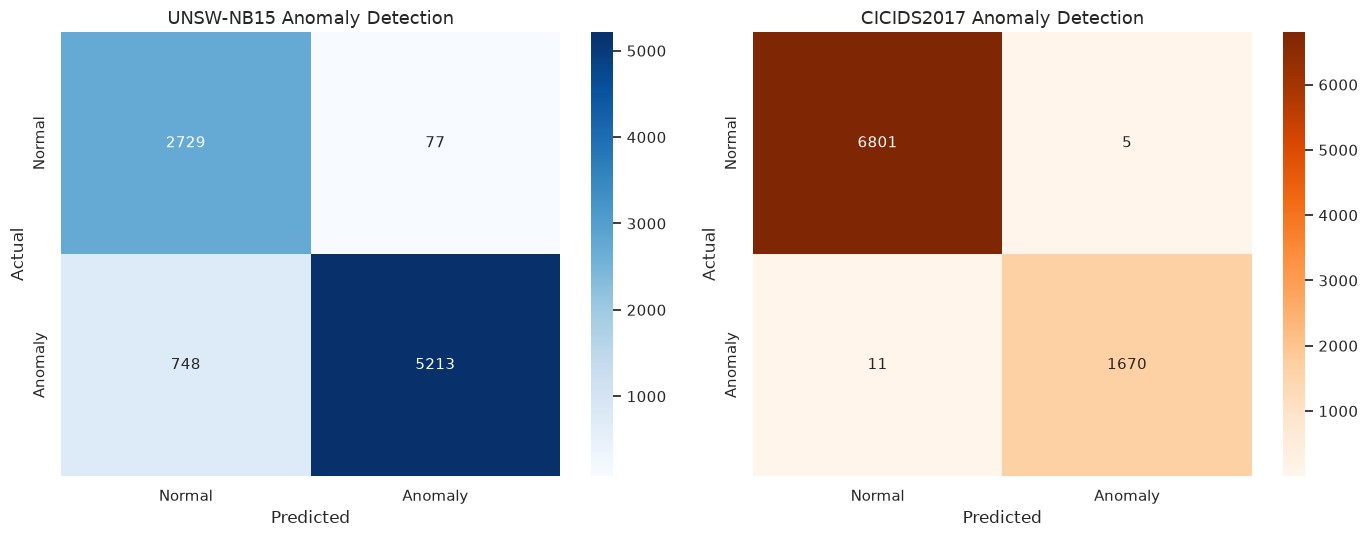

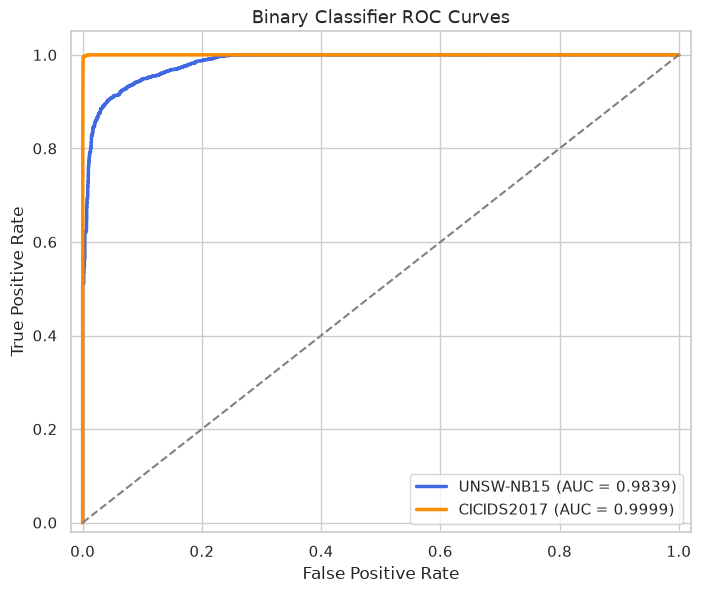

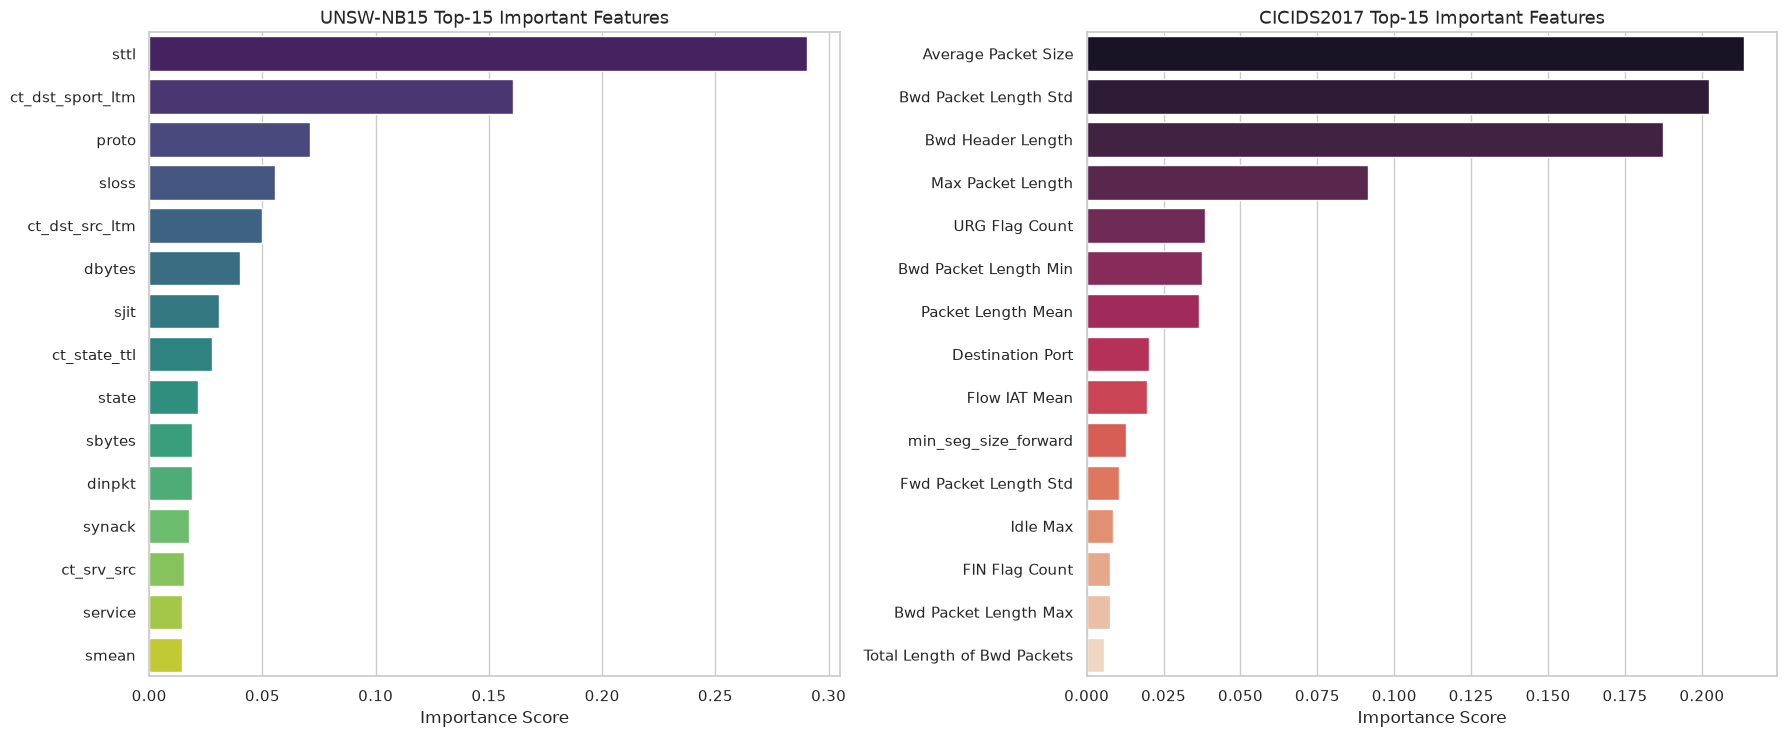

In [13]:
# 1. Plot Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

cm_u = confusion_matrix(y_test_bin, y_pred_bin)
sns.heatmap(cm_u, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Normal', 'Anomaly'], yticklabels=['Normal', 'Anomaly'])
axes[0].set_title('UNSW-NB15 Anomaly Detection')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

cm_c = confusion_matrix(y_test_bin_c, y_pred_bin_c)
sns.heatmap(cm_c, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=['Normal', 'Anomaly'], yticklabels=['Normal', 'Anomaly'])
axes[1].set_title('CICIDS2017 Anomaly Detection')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('plots/binary_confusion_matrices.png', dpi=300)
plt.show()

# 2. Plot ROC Curves
fpr_u, tpr_u, _ = roc_curve(y_test_bin, y_prob_bin)
auc_u = auc(fpr_u, tpr_u)

fpr_c, tpr_c, _ = roc_curve(y_test_bin_c, y_prob_bin_c)
auc_c = auc(fpr_c, tpr_c)

plt.figure(figsize=(8, 6.5))
plt.plot(fpr_u, tpr_u, color='royalblue', lw=2.5, label=f'UNSW-NB15 (AUC = {auc_u:.4f})')
plt.plot(fpr_c, tpr_c, color='darkorange', lw=2.5, label=f'CICIDS2017 (AUC = {auc_c:.4f})')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--', lw=1.5)
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Binary Classifier ROC Curves')
plt.legend(loc='lower right')
plt.savefig('plots/roc_curves.png', dpi=300)
plt.show()

# 3. Plot Top-15 Feature Importances
fig, axes = plt.subplots(1, 2, figsize=(18, 7.5))

# UNSW Feature Importances
imp_u = unsw_bin_clf.feature_importances_
idx_u = np.argsort(imp_u)[::-1][:15]
sns.barplot(x=imp_u[idx_u], y=np.array(X_train.columns)[idx_u], ax=axes[0], palette='viridis', hue=np.array(X_train.columns)[idx_u], legend=False)
axes[0].set_title('UNSW-NB15 Top-15 Important Features')
axes[0].set_xlabel('Importance Score')

# CICIDS Feature Importances
imp_c = cicids_bin_clf.feature_importances_
idx_c = np.argsort(imp_c)[::-1][:15]
sns.barplot(x=imp_c[idx_c], y=np.array(X_train_c.columns)[idx_c], ax=axes[1], palette='rocket', hue=np.array(X_train_c.columns)[idx_c], legend=False)
axes[1].set_title('CICIDS2017 Top-15 Important Features')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('plots/feature_importances.png', dpi=300)
plt.show()

### 7. Training Pipeline Completed!

We have trained and evaluated our network anomaly detection models. The following files are created and ready to be integrated into the FastAPI backend:

**Preprocessors:**
- `models/unsw_preprocessor.joblib`
- `models/cicids_preprocessor.joblib`

**Models:**
- `models/unsw_binary_model.joblib`
- `models/unsw_multiclass_model.joblib`
- `models/cicids_binary_model.joblib`
- `models/cicids_multiclass_model.joblib`

**Plots:**
- `plots/binary_confusion_matrices.png`
- `plots/roc_curves.png`
- `plots/feature_importances.png`